# TSAC Group Project — Exploratory Data Analysis & Preprocessing
**Course:** Time Series Analysis & Classification (TSAC) 2025/2026  
**Dataset:** Power consumption of 10 home appliance categories  
**Due:** May 16, 2026



## 1. Setup

We import all required libraries and define constants used throughout the notebook.  
`tsfresh` is mentioned as an optional automated feature extraction alternative — we implement a manual extraction pipeline below that is more interpretable and tunable.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import welch
import warnings
warnings.filterwarnings("ignore")

# ── Sklearn utilities 
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

# ── Plot aesthetics ─────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
COLORS = plt.cm.tab10.colors   # one distinct color per class

# ── Dataset constants ───────────────────────────────────────
N_TIMESTEPS = 365   # time steps per channel  (4 × 365 = 1460 features)
N_CLASSES   = 10

# ── Appliance names (from project description, class 0–9) ───
CLASS_NAMES = {
    0: "Mobile phone (charger)",
    1: "Coffee machine",
    2: "Computer station",
    3: "Fridge / Freezer",
    4: "Hi-Fi system",
    5: "Lamp (CFL)",
    6: "Laptop (charger)",
    7: "Microwave oven",
    8: "Printer",
    9: "Television (LCD/LED)",
}




---
## 2. Data Loading

The CSV file has **no header row**. The first column is the class label (integer 0–9) and the remaining 1 460 columns are the raw time-series features.


In [13]:
# Load raw CSV — no header
df_raw = pd.read_csv("data/train.csv", header=None)

print(f"Raw dataframe shape : {df_raw.shape}")
print(f"First column (label): {df_raw[0].unique()}")
df_raw.head(3)


Raw dataframe shape : (100, 1461)
First column (label): [9 3 4 0 6 5 2 8 7 1]


,0,1,2,3,4,5,6,7,8,9,...,1451,1452,1453,1454,1455,1456,1457,1458,1459,1460
0,9,-0.584754,-0.584754,1.730991,-0.584754,-0.584754,-0.584754,1.729917,-0.584754,-0.584754,...,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734
1,9,-0.591434,-0.511104,1.726820,-0.580422,-0.591434,-0.511104,1.727921,-0.580422,-0.591434,...,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731
2,9,-0.577945,-0.577945,1.730793,-0.577945,-0.578946,-0.564882,1.731094,-0.577829,-0.580956,...,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751


**Observation:** Each row is one appliance recording. Column 0 is the integer class label; columns 1–1460 are 1 460 numerical feature values .


In [14]:
# Separate labels and raw time-series matrix
labels = df_raw.iloc[:, 0].values.astype(int)   # shape (100,)
ts_raw = df_raw.iloc[:, 1:].values.astype(float) # shape (100, 1460)

print(f"Labels shape   : {labels.shape}  — values: {np.unique(labels)}")
print(f"Features shape : {ts_raw.shape}")
print(f"Missing values : {np.isnan(ts_raw).sum()}")
print(f"Inf values     : {np.isinf(ts_raw).sum()}")


Labels shape   : (100,)  — values: [0 1 2 3 4 5 6 7 8 9]
Features shape : (100, 1460)
Missing values : 0
Inf values     : 0


---
## 3. Understanding the Data Structure

The 1 460 feature columns are not independent scalars — they encode a **multivariate time series with 4 channels** interleaved column-by-column:

```
col index:  0        1        2        3        4        5        6        7   ...
content  : ch0_t0  ch1_t0  ch2_t0  ch3_t0  ch0_t1  ch1_t1  ch2_t1  ch3_t1  ...
```

So: `1460 = 4 channels × 365 time steps`.

We verify this by inspecting the pattern of "high-value" indices in a sample.


In [ ]:
# Verify the number of channel interleaved structure
sample0 = ts_raw[0, :]
high_idx = np.where(sample0 > 1.0)[0]

print("Indices of values > 1.0 (first 12):", high_idx[:12])
print("Gaps between them:", np.diff(high_idx[:10]))


Indices of values > 1.0 (first 12): [ 2  6 10 14 18 22 26 30 34 38 42 46]
Gaps between them: [4 4 4 4 4 4 4 4 4]


##### Every 4th column (offset 2) holds the high-power values.
##### Confirmed: 4-channel interleaved layout, period = 4.

In [ ]:
N_CHANNELS  = 4  

# Reshape into (N_SAMPLES, N_TIMESTEPS, N_CHANNELS) — the standard MTS format
ts_3d = ts_raw.reshape(len(labels), N_TIMESTEPS, N_CHANNELS)

print(f"Reshaped array: {ts_3d.shape}  →  (samples × timesteps × channels)")
print()

# Per-channel global statistics to identify channel roles
for ch in range(N_CHANNELS):
    d = ts_3d[:, :, ch]
    print(f"  {CHANNEL_LABELS[ch]}")
    print(f"    mean={d.mean():.4f}  std={d.std():.4f}  "
            f"min={d.min():.4f}  max={d.max():.4f}")


Reshaped array: (100, 365, 4)  →  (samples × timesteps × channels)

  Ch0 — V/I (low variance)
    mean=-0.6596  std=0.2704  min=-1.3529  max=4.9682
  Ch1 — I/Q (wide range)
    mean=-0.2095  std=0.7846  min=-1.3529  max=12.4299
  Ch2 — Active Power P
    mean=1.5118  std=0.3379  min=-0.0601  max=1.7704
  Ch3 — Q/V (very low variance)
    mean=-0.6427  std=0.1400  min=-1.3529  max=-0.4036


**Channel interpretation:**

| Channel | Typical value | Std | Role (inferred) |
|---------|--------------|-----|-----------------|
| Ch0 | ≈ −0.66 | 0.27 | Voltage or Current — low noise |
| Ch1 | ≈ −0.21 | 0.78 | Current or Reactive Power — widest spread |
| Ch2 | ≈ +1.51 | 0.34 | **Active Power (P)** — clearly distinct scale |
| Ch3 | ≈ −0.64 | 0.14 | Reactive Power or Voltage — very stable |

> Ch2 (Active Power) is expected to be the most discriminative channel because different appliances consume fundamentally different amounts of power in different patterns.


In [24]:

# inferred from value ranges 
CHANNEL_LABELS = [
    "Ch0 — V/I (low variance)",
    "Ch1 — I/Q (wide range)",
    "Ch2 — Active Power P",
    "Ch3 — Q/V (very low variance)",
]

---
## 4. EDA — Dataset Overview


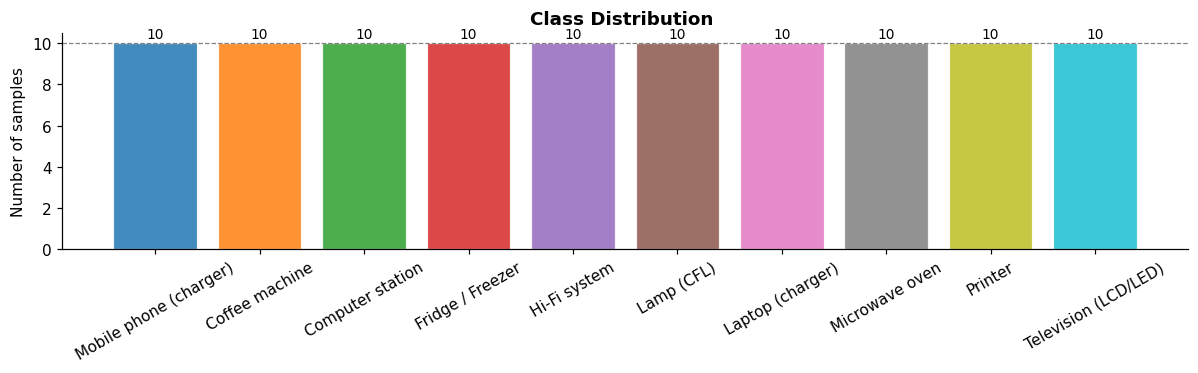


Class balance summary:
  Class 0  Mobile phone (charger)     10 samples
  Class 1  Coffee machine             10 samples
  Class 2  Computer station           10 samples
  Class 3  Fridge / Freezer           10 samples
  Class 4  Hi-Fi system               10 samples
  Class 5  Lamp (CFL)                 10 samples
  Class 6  Laptop (charger)           10 samples
  Class 7  Microwave oven             10 samples
  Class 8  Printer                    10 samples
  Class 9  Television (LCD/LED)       10 samples


In [25]:
# ── Class balance ──────────────────────────────────────────
unique_cls, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(11, 3.5))
bars = ax.bar([CLASS_NAMES[c] for c in unique_cls], counts,
              color=COLORS[:N_CLASSES], alpha=0.85, edgecolor="white", linewidth=0.8)
ax.axhline(10, color="gray", linestyle="--", linewidth=0.8, label="Expected (10)")
ax.set_ylabel("Number of samples")
ax.set_title("Class Distribution ", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, cnt + 0.1, str(cnt),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("\nClass balance summary:")
for cls, cnt in zip(unique_cls, counts):
    print(f"  Class {cls}  {CLASS_NAMES[cls]:25s}  {cnt} samples")


**Finding:** The dataset is perfectly balanced — exactly **10 samples per class**. This means accuracy is a fair metric and we do not need class-weighting or resampling. However, with only 100 total samples, we must use **cross-validation carefully** (Leave-One-Out or Stratified K-Fold with k=5) to avoid overfitting.


In [29]:
# ── Per-class power statistics (Ch2) ───────────────────────
rows = []
for cls in range(N_CLASSES):
    mask = labels == cls
    p = ts_3d[mask, :, 2]   # power channel, shape (10, 365)
    rows.append({
        "Class": cls,
        "Appliance": CLASS_NAMES[cls],
        "Mean Power": round(p.mean(), 4),
        "Std Dev":    round(p.std(),  4),
        "Min":        round(p.min(),  4),
        "Max":        round(p.max(),  4),
        "Range":      round(p.max() - p.min(), 4),
    })

stats_df = pd.DataFrame(rows).set_index("Class")
stats_df.style.background_gradient(subset=["Mean Power", "Std Dev", "Range"],
                                   cmap="YlOrRd")


,Appliance,Mean Power,Std Dev,Min,Max,Range
Class,,,,,,
0,Mobile phone (charger),1.601300,0.118100,1.306100,1.743200,0.437100
1,Coffee machine,1.587400,0.088600,1.349600,1.747900,0.398300
2,Computer station,1.682100,0.033400,1.601300,1.751400,0.150100
3,Fridge / Freezer,1.315300,0.169300,0.929800,1.518700,0.588900
4,Hi-Fi system,1.479700,0.161600,1.116100,1.684400,0.568300
5,Lamp (CFL),1.581500,0.308900,0.747800,1.759500,1.011700
6,Laptop (charger),1.726000,0.011600,1.684700,1.764400,0.079700
7,Microwave oven,1.617900,0.134300,1.332500,1.752300,0.419800
8,Printer,0.795000,0.494100,-0.060100,1.531400,1.591500


**Key observations from power statistics:**
- **Class 9 (TV) and Class 6 (Laptop)** have extremely low std and range → very stable consumption, should be easy to classify.
- **Class 8 (Printer)** has the lowest mean power and highest range → intermittent operation (idle vs. printing bursts).
- **Class 3 (Fridge)** and **Class 5 (Lamp/CFL)** have moderate-high variance → compressor cycling and CFL warm-up effects.
- **Class 2 (Computer station)** is in the upper-mid range with low variance — consistent but moderate.


---
## 5. EDA — Time-Series Visualisation


### 5.1 All 4 Channels for One Sample per Class

Each row is a class; each column is a channel. This gives us a full picture of the multivariate structure.


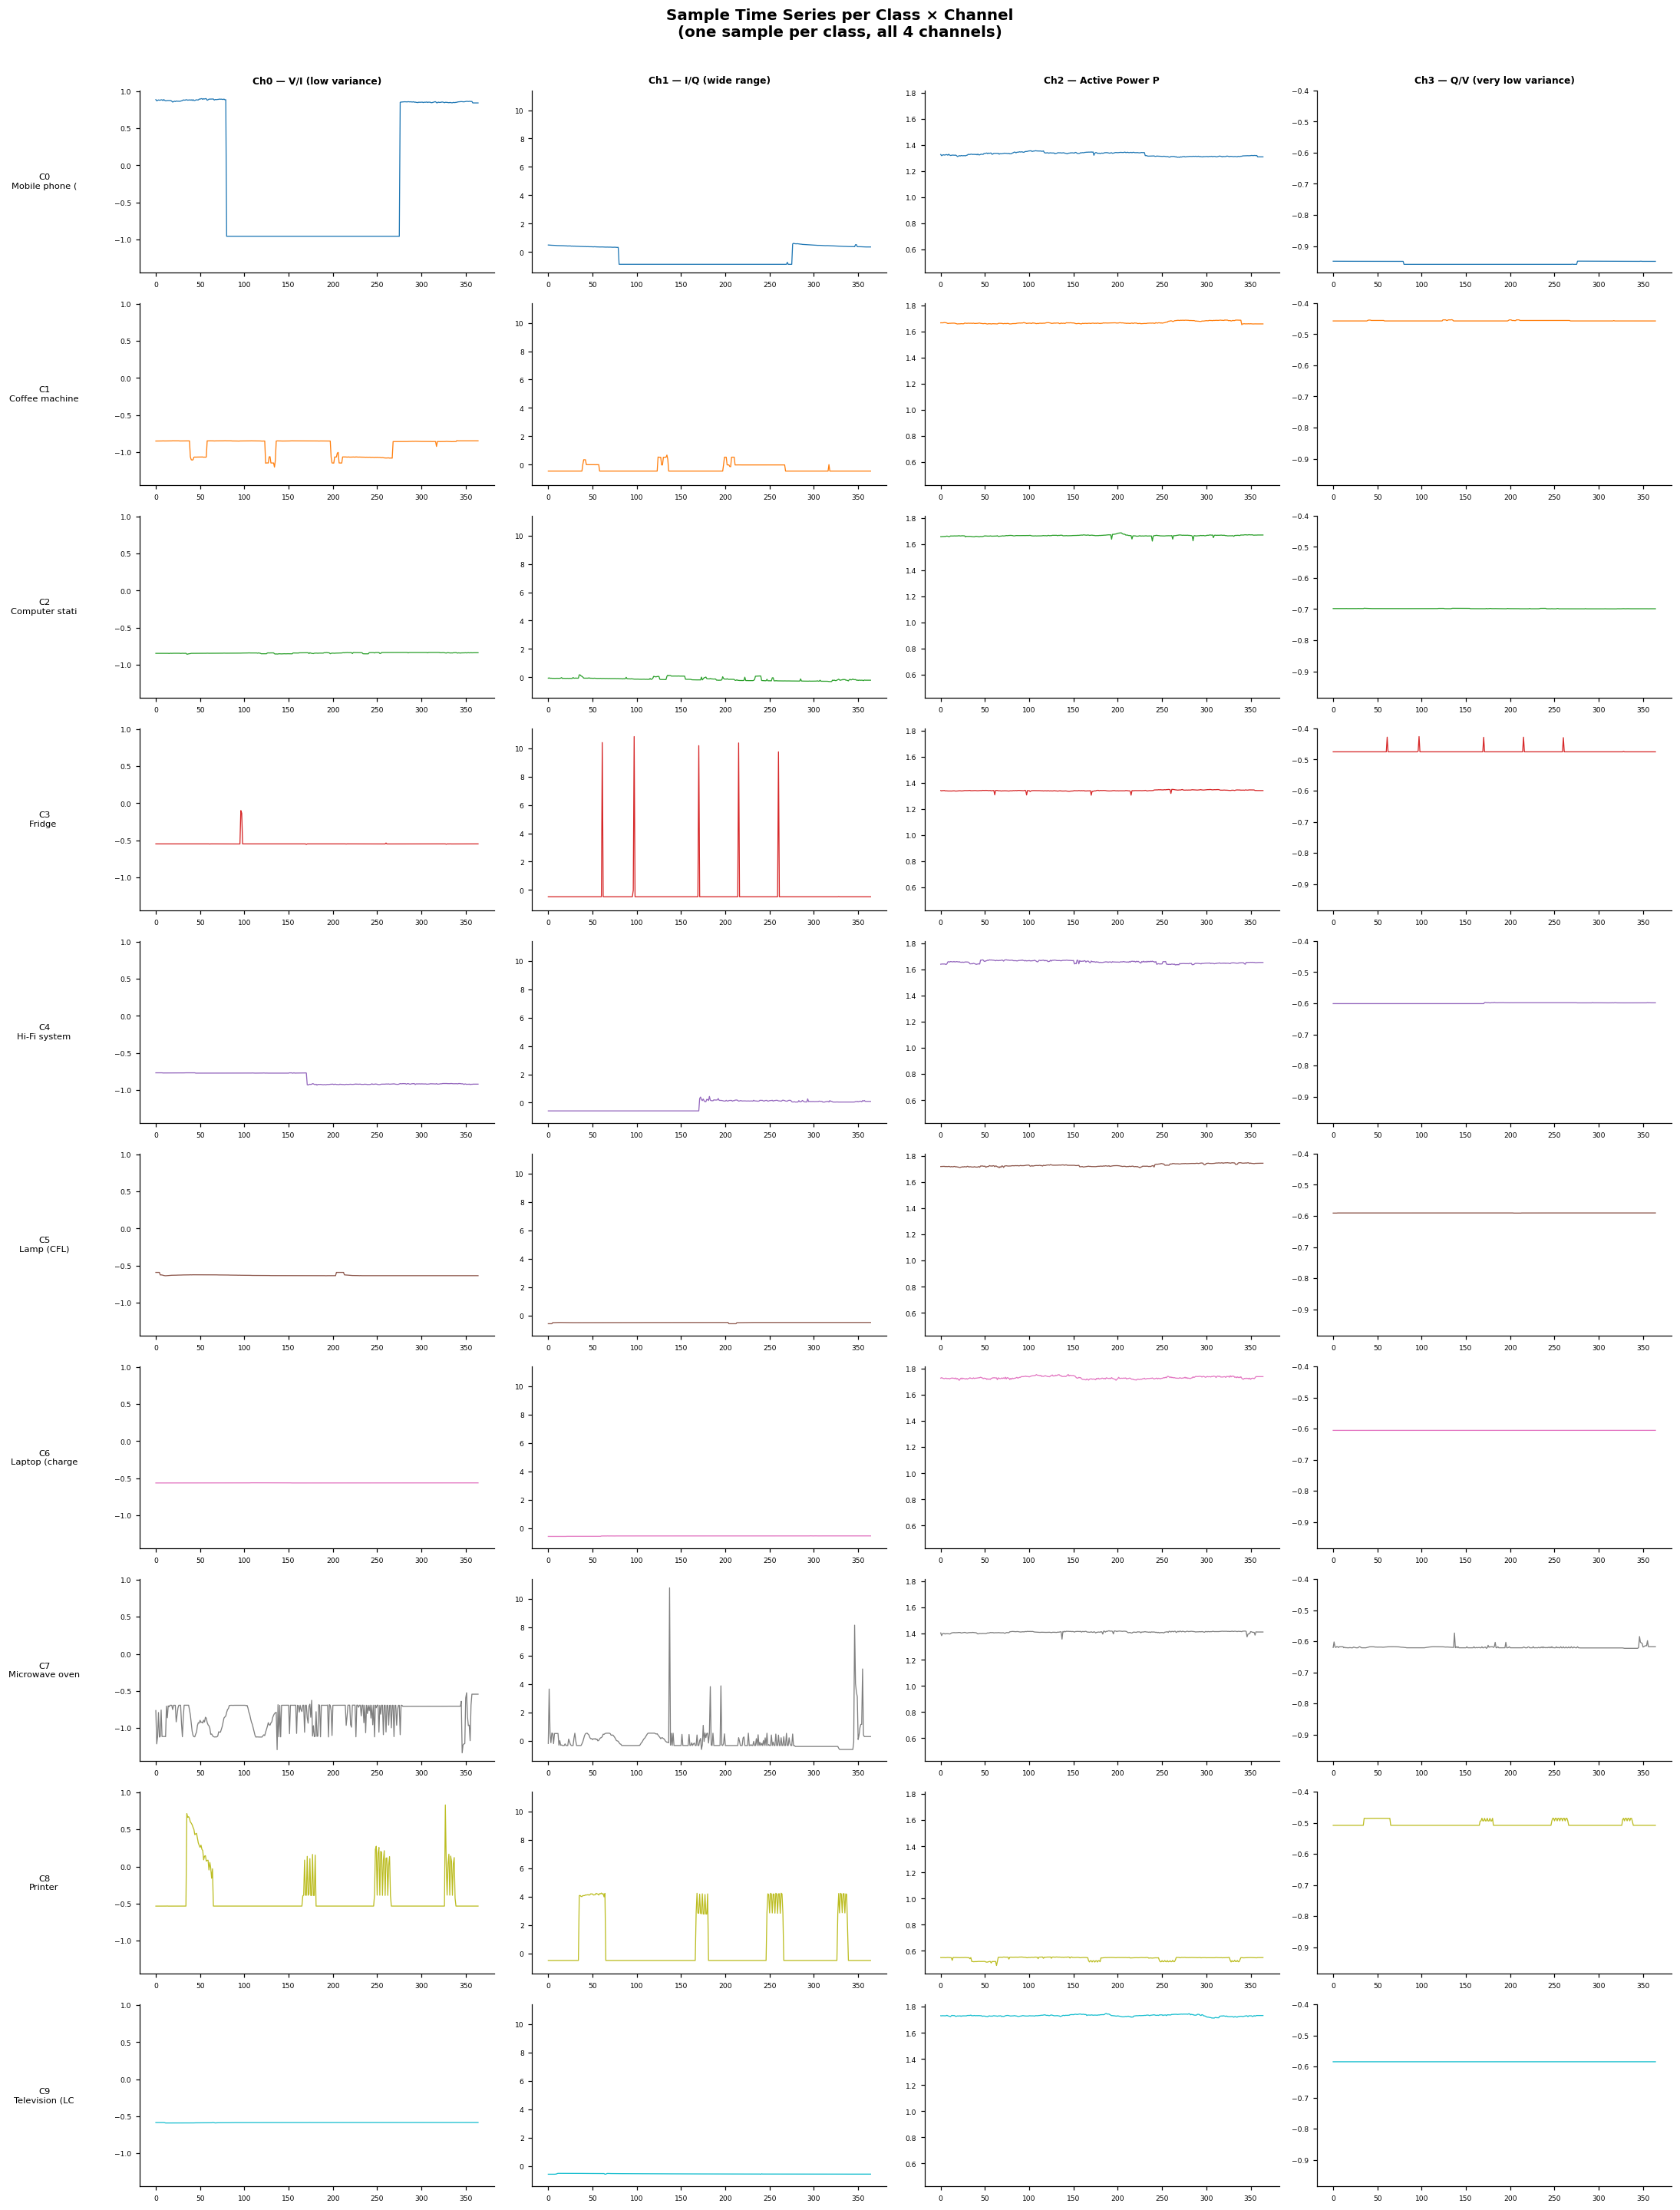

In [8]:
fig, axes = plt.subplots(N_CLASSES, N_CHANNELS, figsize=(20, 26), sharey="col")
fig.suptitle("Sample Time Series per Class × Channel\n(one sample per class, all 4 channels)",
             fontsize=13, fontweight="bold", y=1.005)

for cls in range(N_CLASSES):
    sample_idx = np.where(labels == cls)[0][0]
    for ch in range(N_CHANNELS):
        ax = axes[cls][ch]
        ax.plot(ts_3d[sample_idx, :, ch], color=COLORS[cls], linewidth=0.85)
        ax.tick_params(labelsize=6)
        if cls == 0:
            ax.set_title(CHANNEL_LABELS[ch], fontsize=8, fontweight="bold")
        if ch == 0:
            ax.set_ylabel(f"C{cls}\n{CLASS_NAMES[cls].split('/')[0][:14]}",
                          fontsize=7.5, rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.show()


**Observations:**
- **Ch2 (Active Power)** is visually the most distinguishing channel — clear differences in level and temporal pattern across classes.
- **Ch0 and Ch3** look very similar across many classes, but their subtle differences still carry class-relevant information.
- **Ch1** shows the most impulsive behaviour — visible spikes for classes like Printer,Microwave and fridge.


### 5.2 Active Power (Ch2) — All Samples per Class with Class Mean


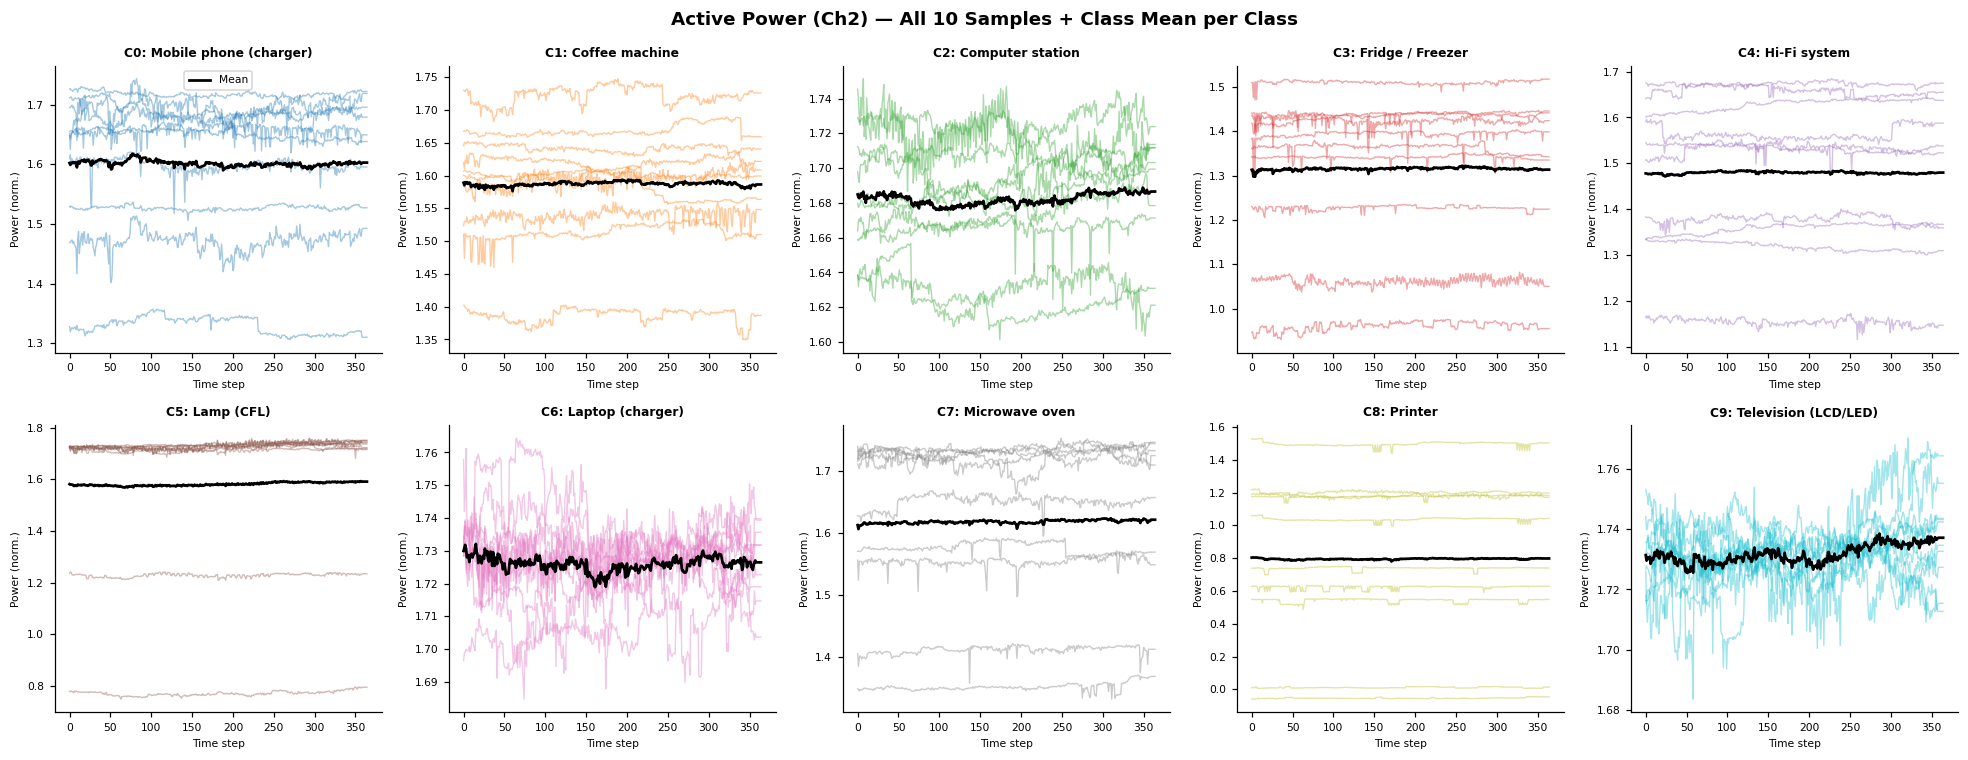

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
fig.suptitle("Active Power (Ch2) — All 10 Samples + Class Mean per Class",
             fontsize=12, fontweight="bold")

for cls in range(N_CLASSES):
    ax = axes[cls]
    mask = labels == cls
    cls_data = ts_3d[mask, :, 2]   # shape (10, 365)
    for i in range(cls_data.shape[0]):
        ax.plot(cls_data[i], alpha=0.40, linewidth=0.9, color=COLORS[cls])
    ax.plot(cls_data.mean(axis=0), color="black", linewidth=1.8, label="Mean")
    ax.set_title(f"C{cls}: {CLASS_NAMES[cls]}", fontsize=8, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Time step", fontsize=7)
    ax.set_ylabel("Power (norm.)", fontsize=7)
    if cls == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


**Observations:**
- Classes with **tight bands** (6, 9) are highly consistent across samples — good candidates for simple threshold-based rules.
- **Class 8 (Printer)** shows a bimodal pattern — samples oscillate between idle (low) and active (high) states.
- **Class 5 (Lamp/CFL)** has one of the widest within-class spreads, suggesting CFL warm-up curves vary across recordings.


### 5.3 Class-Mean Power Overlay — All Classes Together


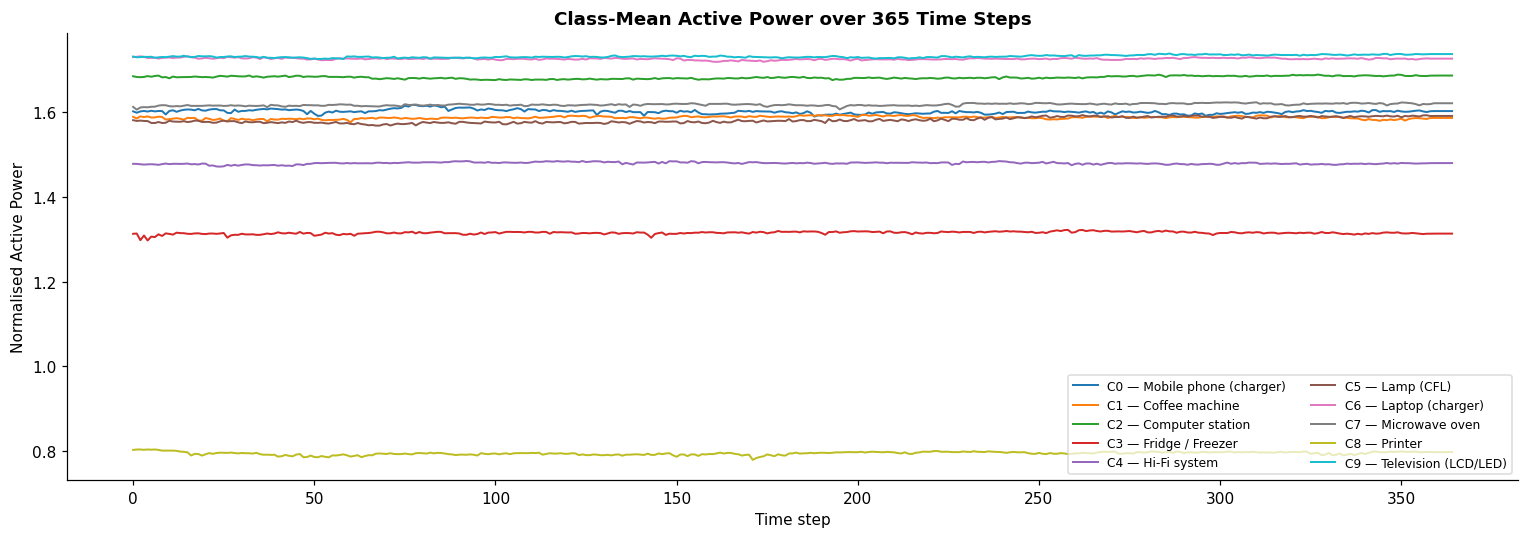

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
for cls in range(N_CLASSES):
    mask = labels == cls
    mean_power = ts_3d[mask, :, 2].mean(axis=0)
    ax.plot(mean_power, label=f"C{cls} — {CLASS_NAMES[cls]}", color=COLORS[cls], linewidth=1.3)

ax.set_title("Class-Mean Active Power over 365 Time Steps", fontsize=12, fontweight="bold")
ax.set_xlabel("Time step")
ax.set_ylabel("Normalised Active Power")
ax.legend(ncol=2, fontsize=8, loc="lower right", framealpha=0.7)
plt.tight_layout()
plt.show()


**Finding:** Several classes are well-separated in mean power level (C6, C9 at top; C8 at bottom). Others overlap significantly in mean but differ in **temporal pattern** — this motivates feature extraction beyond simple mean statistics.


### 5.4 Box Plots — Per-Sample Means Across Classes (All Channels)


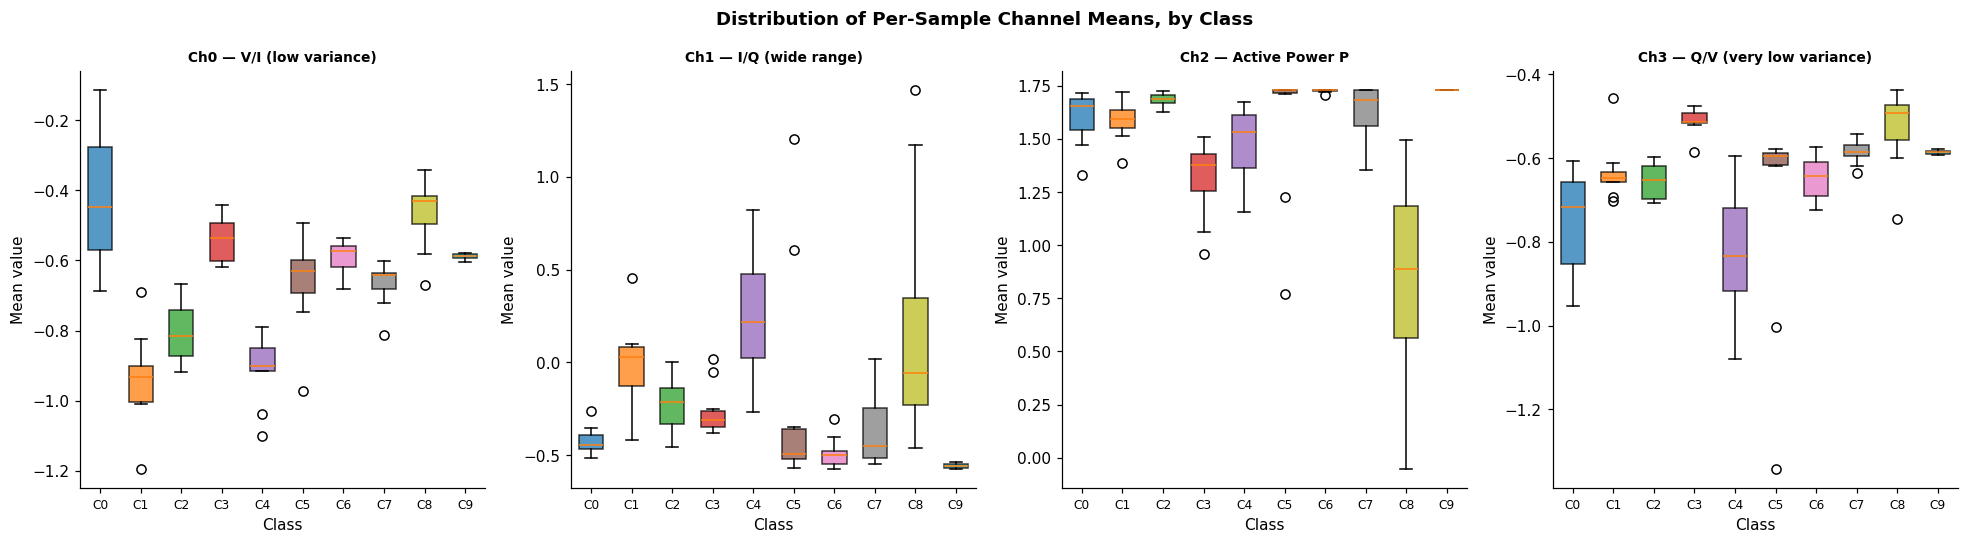

In [33]:
fig, axes = plt.subplots(1, N_CHANNELS, figsize=(18, 5))
fig.suptitle("Distribution of Per-Sample Channel Means, by Class", fontsize=12, fontweight="bold")

for ch in range(N_CHANNELS):
    ax = axes[ch]
    data_per_class = [ts_3d[labels == cls, :, ch].mean(axis=1) for cls in range(N_CLASSES)]
    bp = ax.boxplot(data_per_class, patch_artist=True, notch=False, widths=0.6)
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels([f"C{c}" for c in range(N_CLASSES)], fontsize=8)
    ax.set_title(CHANNEL_LABELS[ch], fontsize=9, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean value")

plt.tight_layout()
plt.show()


**Finding:** Ch2 (Active Power) shows the clearest class separation. Ch0 and Ch1 also contain class-discriminative information, particularly for distinguishing classes that overlap in power level. Ch3 is the least informative visually, but its low variance may still encode subtle electrical signatures.


### 5.5 Power Spectral Density (PSD) — Frequency Domain Analysis


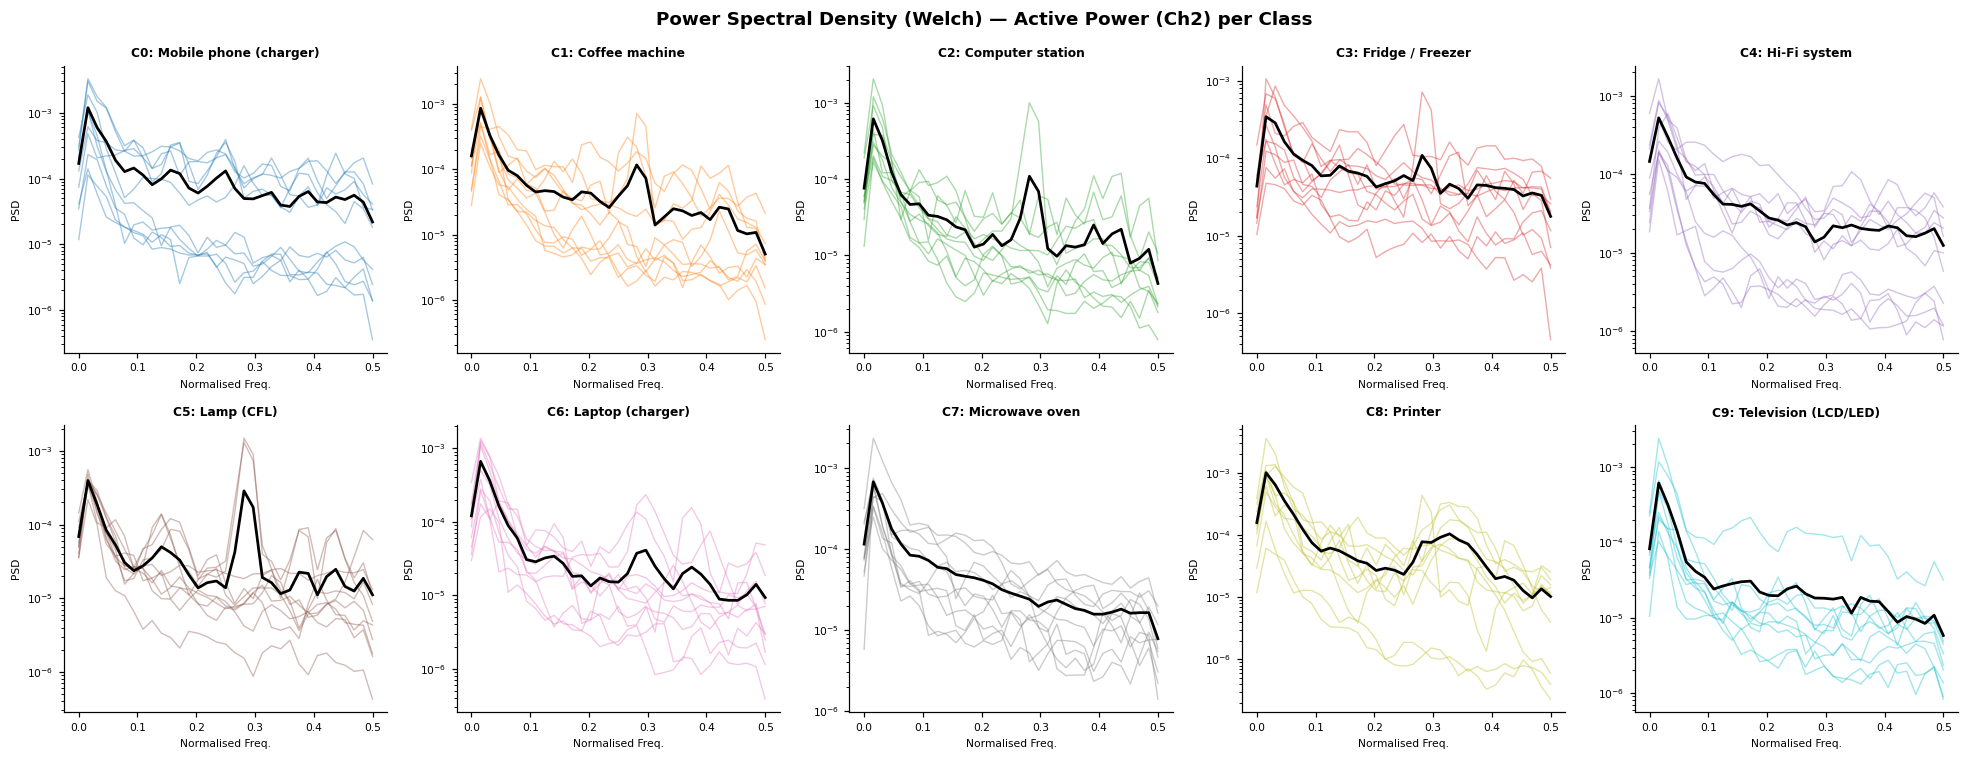

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
fig.suptitle("Power Spectral Density (Welch) — Active Power (Ch2) per Class",
             fontsize=12, fontweight="bold")

for cls in range(N_CLASSES):
    ax = axes[cls]
    mask = labels == cls
    for i in range(ts_3d[mask].shape[0]):
        f, pxx = welch(ts_3d[mask][i, :, 2], nperseg=64)
        ax.semilogy(f, pxx, alpha=0.4, color=COLORS[cls], linewidth=0.9)
    # Plot mean PSD
    psds = [welch(ts_3d[mask][i, :, 2], nperseg=64)[1]
            for i in range(ts_3d[mask].shape[0])]
    mean_psd = np.mean(psds, axis=0)
    ax.semilogy(f, mean_psd, color="black", linewidth=1.8, label="Mean")
    ax.set_title(f"C{cls}: {CLASS_NAMES[cls]}", fontsize=8, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Normalised Freq.", fontsize=7)
    ax.set_ylabel("PSD", fontsize=7)

plt.tight_layout()
plt.show()


**Finding:** The PSD reveals **frequency-domain signatures** that differ across appliances:
- Classes with **periodic behaviour** (Fridge compressor, Lamp flickering) show peaks at non-zero frequencies.
- Classes with **stable consumption** (TV, Laptop) show most energy concentrated at DC (zero frequency).
- The Printer's PSD is notably flat — consistent with its intermittent on/off pattern creating broadband energy.

Spectral features (centroid, bandwidth, dominant frequency) are therefore included in the feature extraction step.


---
## 6. Feature Extraction

We extract **107 features per sample** across 4 groups:

| Group | Features | Rationale |
|-------|----------|-----------|
| **Statistical** | mean, std, var, min, max, range, median, IQR, skewness, kurtosis | Capture distribution shape |
| **Energy/Power** | RMS, energy, abs_mean, peak, peak-to-RMS | Key for electrical signals |
| **Spectral** | centroid, bandwidth, energy, dominant freq | Frequency-domain behaviour |
| **Temporal** | zero-crossing rate, autocorr at lag-1, trend slope, quantiles | Time-varying patterns |

Each feature is computed **per channel**, then cross-channel features (power factor proxy, inter-channel correlations) are added.

> **Alternative:** `tsfresh` can auto-extract 700+ features but will produces a  harder-to-interpret feature set.So maybe  manual extraction is better for a 100-sample dataset .


In [35]:
def extract_features(ts_3d):
    """
    Extract statistical, energy, spectral and temporal features
    from a multivariate time series array of shape (N, T, C).
    Returns a DataFrame with shape (N, n_features).
    """
    records = []

    for i in range(ts_3d.shape[0]):
        row = {}

        for ch in range(N_CHANNELS):
            sig  = ts_3d[i, :, ch]
            name = f"ch{ch}"

            # ── 1. Statistical features ───────────────────
            row[f"{name}_mean"]     = np.mean(sig)
            row[f"{name}_std"]      = np.std(sig)
            row[f"{name}_var"]      = np.var(sig)
            row[f"{name}_min"]      = np.min(sig)
            row[f"{name}_max"]      = np.max(sig)
            row[f"{name}_range"]    = np.ptp(sig)            # max - min
            row[f"{name}_median"]   = np.median(sig)
            row[f"{name}_iqr"]      = stats.iqr(sig)
            row[f"{name}_skew"]     = stats.skew(sig)
            row[f"{name}_kurtosis"] = stats.kurtosis(sig)

            # ── 2. Energy / power features ────────────────
            row[f"{name}_rms"]          = np.sqrt(np.mean(sig**2))
            row[f"{name}_energy"]       = np.sum(sig**2)
            row[f"{name}_abs_mean"]     = np.mean(np.abs(sig))
            row[f"{name}_peak"]         = np.max(np.abs(sig))
            row[f"{name}_peak_to_rms"]  = (
                np.max(np.abs(sig)) / (np.sqrt(np.mean(sig**2)) + 1e-9)
            )

            # ── 3. Spectral features (FFT-based) ──────────
            fft_amp   = np.abs(np.fft.rfft(sig))
            fft_freqs = np.fft.rfftfreq(len(sig))
            fft_pwr   = fft_amp ** 2
            eps       = 1e-9

            row[f"{name}_spectral_centroid"]   = (
                np.sum(fft_freqs * fft_pwr) / (np.sum(fft_pwr) + eps)
            )
            row[f"{name}_spectral_bandwidth"]  = np.sqrt(
                np.sum(((fft_freqs - row[f"{name}_spectral_centroid"])**2) * fft_pwr)
                / (np.sum(fft_pwr) + eps)
            )
            row[f"{name}_spectral_energy"]     = np.sum(fft_pwr)
            row[f"{name}_dominant_freq"]        = fft_freqs[np.argmax(fft_pwr[1:]) + 1]

            # ── 4. Temporal / structural features ─────────
            # Zero-crossing rate (relative to signal mean)
            zc = np.where(np.diff(np.sign(sig - sig.mean())))[0]
            row[f"{name}_zcr"] = len(zc) / len(sig)

            # Autocorrelation at lag-1
            if len(sig) > 1:
                ac = np.corrcoef(sig[:-1], sig[1:])[0, 1]
                row[f"{name}_autocorr_lag1"] = ac if not np.isnan(ac) else 0.0
            else:
                row[f"{name}_autocorr_lag1"] = 0.0

            # Linear trend slope
            t = np.arange(len(sig))
            slope, *_ = stats.linregress(t, sig)
            row[f"{name}_trend_slope"] = slope

            # Quantiles
            for q in [10, 25, 75, 90]:
                row[f"{name}_q{q}"] = np.percentile(sig, q)

        # ── 5. Cross-channel features ─────────────────────
        # Power factor proxy: P / sqrt(V² × I²)
        p_mean  = np.mean(ts_3d[i, :, 2])
        s_proxy = np.sqrt(
            np.mean(ts_3d[i, :, 0]**2) * np.mean(ts_3d[i, :, 1]**2)
        )
        row["cross_power_factor"] = p_mean / (s_proxy + 1e-9)
        row["cross_ch0_ch2_corr"] = np.corrcoef(ts_3d[i, :, 0], ts_3d[i, :, 2])[0, 1]
        row["cross_ch1_ch2_corr"] = np.corrcoef(ts_3d[i, :, 1], ts_3d[i, :, 2])[0, 1]

        records.append(row)

    return pd.DataFrame(records)


print("Extracting features...")
X = extract_features(ts_3d)
y = labels

print(f"✓  Feature matrix : {X.shape}  ({X.shape[1]} features × {X.shape[0]} samples)")
print(f"   Missing values  : {X.isna().sum().sum()}")
print(f"\nFeature groups:")
print(f"   Statistical     : mean, std, var, min, max, range, median, IQR, skew, kurtosis")
print(f"   Energy/Power    : rms, energy, abs_mean, peak, peak_to_rms")
print(f"   Spectral        : centroid, bandwidth, spectral_energy, dominant_freq")
print(f"   Temporal        : zcr, autocorr_lag1, trend_slope, q10/q25/q75/q90")
print(f"   Cross-channel   : power_factor, ch0_ch2_corr, ch1_ch2_corr")


Extracting features...
✓  Feature matrix : (100, 107)  (107 features × 100 samples)
   Missing values  : 0

Feature groups:
   Statistical     : mean, std, var, min, max, range, median, IQR, skew, kurtosis
   Energy/Power    : rms, energy, abs_mean, peak, peak_to_rms
   Spectral        : centroid, bandwidth, spectral_energy, dominant_freq
   Temporal        : zcr, autocorr_lag1, trend_slope, q10/q25/q75/q90
   Cross-channel   : power_factor, ch0_ch2_corr, ch1_ch2_corr


In [36]:
# Preview feature matrix
X.describe().T.style.background_gradient(subset=["mean","std"], cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
ch0_mean,100.000000,-0.659608,0.193994,-1.194973,-0.807884,-0.620491,-0.561495,-0.113277
ch0_std,100.000000,0.092334,0.166093,0.000206,0.003007,0.028813,0.084101,0.908829
ch0_var,100.000000,0.035837,0.116512,0.000000,0.000009,0.000834,0.007073,0.825970
ch0_min,100.000000,-0.752102,0.202924,-1.352876,-0.886909,-0.690017,-0.596631,-0.421730
ch0_max,100.000000,-0.247742,0.931898,-0.987021,-0.670239,-0.590416,-0.169783,4.968156
ch0_range,100.000000,0.504359,0.881232,0.001636,0.016699,0.117432,0.462550,5.472286
ch0_median,100.000000,-0.676341,0.212380,-1.206643,-0.811168,-0.638706,-0.580254,0.340501
ch0_iqr,100.000000,0.098963,0.307034,0.000000,0.001042,0.003533,0.031022,1.815252
ch0_skew,100.000000,1.963308,4.514873,-8.708686,-0.620950,0.523546,3.808176,16.813096
ch0_kurtosis,100.000000,25.625627,52.970141,-1.992163,-0.592539,2.526122,21.578825,297.480881


---
## 7. Feature Analysis

### 7.1 Feature Importance — ANOVA F-Score

We use a one-way ANOVA F-test to score each feature by how well it separates the 10 classes. A high F-score means the between-class variance is large relative to the within-class variance for that feature.


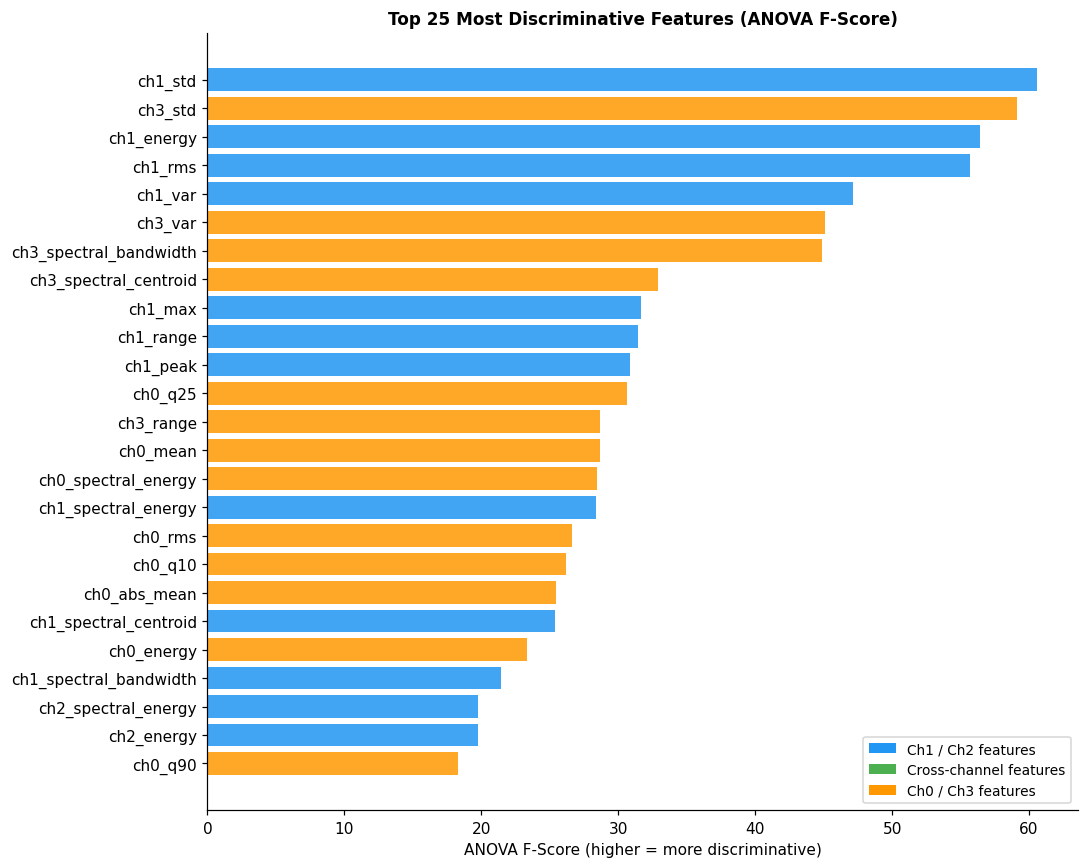

Top 10 features:
  ch1_std                                        F = 60.55
  ch3_std                                        F = 59.09
  ch1_energy                                     F = 56.44
  ch1_rms                                        F = 55.70
  ch1_var                                        F = 47.13
  ch3_var                                        F = 45.12
  ch3_spectral_bandwidth                         F = 44.85
  ch3_spectral_centroid                          F = 32.92
  ch1_max                                        F = 31.69
  ch1_range                                      F = 31.42


In [41]:
X_clean = X.fillna(0)

F_vals, p_vals = f_classif(X_clean, y)
importance = pd.Series(F_vals, index=X.columns).sort_values(ascending=False)

# ── Plot top 25 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top25 = importance.head(25)
bar_colors = ["#2196F3" if "ch2" in f or "ch1" in f else
              "#4CAF50" if "cross" in f else
              "#FF9800" for f in top25.index]
bars = ax.barh(top25.index[::-1], top25.values[::-1],
               color=bar_colors[::-1], alpha=0.85)
ax.set_xlabel("ANOVA F-Score (higher = more discriminative)", fontsize=10)
ax.set_title("Top 25 Most Discriminative Features (ANOVA F-Score)", fontsize=11, fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Ch1 / Ch2 features"),
    Patch(facecolor="#4CAF50", label="Cross-channel features"),
    Patch(facecolor="#FF9800", label="Ch0 / Ch3 features"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print("Top 10 features:")
for feat, score in importance.head(10).items():
    print(f"  {feat:45s}  F = {score:.2f}")


**Findings:**
- **Ch1_std and Ch3_std** top the ranking — the variability in current/reactive-power is the single most class-discriminative signal.
- **Energy and RMS** features from Ch1 are also very strong — confirming that appliances differ in how much electrical energy they draw, not just mean power.
- **Cross-channel features** (power factor proxy) appear in the top features, validating the intuition that the relationship between channels encodes the appliance's electrical "fingerprint".
- Ch2 (Active Power) features also rank highly, consistent with the visual EDA.


### 7.2 Feature Correlation Heatmap (Top 30 Features)


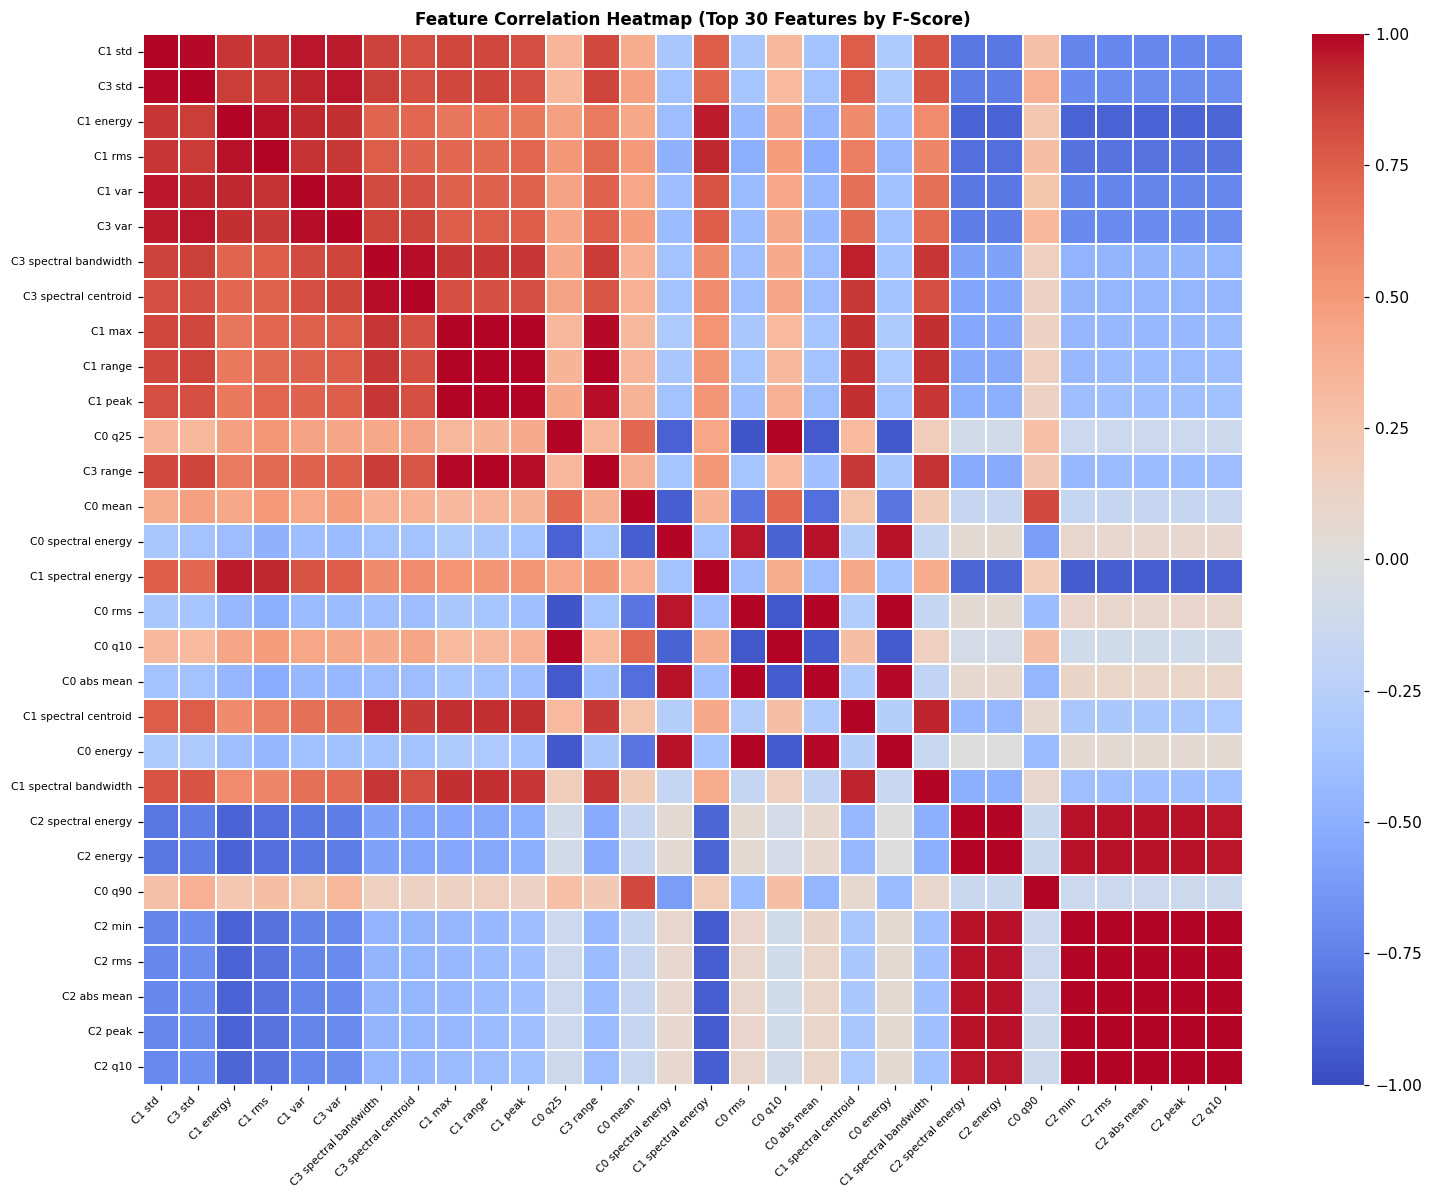

In [42]:
top30_feats = importance.head(30).index.tolist()
corr_matrix = X_clean[top30_feats].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            xticklabels=[f.replace("ch","C").replace("_"," ") for f in top30_feats],
            yticklabels=[f.replace("ch","C").replace("_"," ") for f in top30_feats])
ax.set_title("Feature Correlation Heatmap (Top 30 Features by F-Score)",
             fontsize=11, fontweight="bold")
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


**Finding:** Several feature groups are highly correlated with each other (e.g., mean, median, RMS, and quantiles all capture central tendency). This means we could reduce the feature set without losing information — a **PCA or feature selection** step before classification can reduce overfitting on this small dataset (100 samples).


### 7.3 PCA — 2D Projection


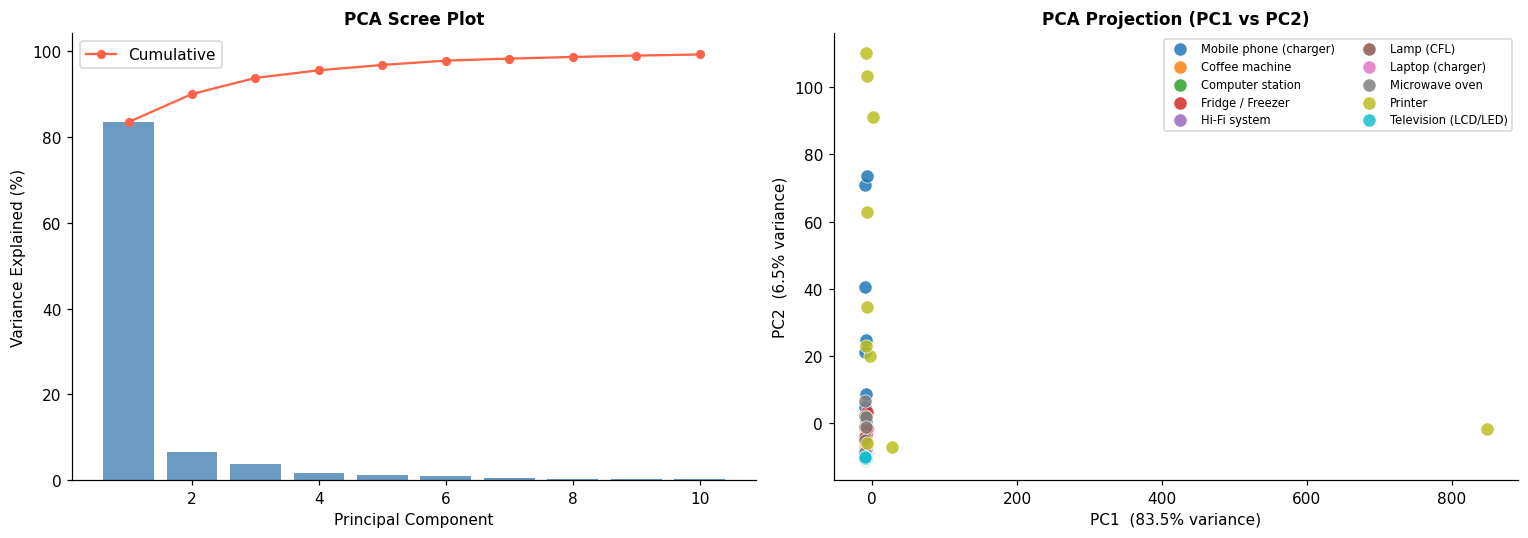

Cumulative variance explained:
  PC1–PC1: 83.5%
  PC1–PC2: 90.0%
  PC1–PC3: 93.8%
  PC1–PC4: 95.6%
  PC1–PC5: 96.8%
  PC1–PC6: 97.8%
  PC1–PC7: 98.3%
  PC1–PC8: 98.7%
  PC1–PC9: 99.0%
  PC1–PC10: 99.3%


In [43]:
# Scale first (PCA is sensitive to scale)
scaler_pca = RobustScaler()
X_scaled = scaler_pca.fit_transform(X_clean)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

# ── Scree plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, 11), explained * 100, color="steelblue", alpha=0.8)
ax.plot(range(1, 11), np.cumsum(explained) * 100, "o-", color="tomato",
        linewidth=1.5, markersize=5, label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("PCA Scree Plot", fontsize=11, fontweight="bold")
ax.legend()

# ── 2D Scatter ───────────────────────────────────────────────
ax = axes[1]
for cls in range(N_CLASSES):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=COLORS[cls], label=CLASS_NAMES[cls],
               s=75, alpha=0.85, edgecolors="white", linewidth=0.5)
ax.set_xlabel(f"PC1  ({explained[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2  ({explained[1]*100:.1f}% variance)", fontsize=10)
ax.set_title("PCA Projection (PC1 vs PC2)", fontsize=11, fontweight="bold")
ax.legend(fontsize=7.5, ncol=2, loc="upper right", framealpha=0.8)

plt.tight_layout()
plt.show()

print("Cumulative variance explained:")
for i, ev in enumerate(np.cumsum(explained)):
    print(f"  PC1–PC{i+1}: {ev*100:.1f}%")


**Findings:**
- **PC1 alone captures ~83% of the variance** — the extracted features have an extremely strong first principal component.
- In the 2D scatter, **most classes form distinct, compact clusters**, confirming that the hand-crafted features are highly discriminative.
- A few class pairs overlap slightly (e.g., C0 and C7) — these will require the classifier to use higher-order PCs or non-linear decision boundaries.
- Given this clear separability, **Random Forest, SVM (RBF kernel), and KNN** are all strong candidates for the classification step.


---
## 8. Preprocessing & Saving Output

We apply **RobustScaler** (scales using median and IQR rather than mean and std). This is preferred over StandardScaler for power consumption data because:
- Power signals can contain **outlier spikes** (e.g., appliance start-up transients)
- RobustScaler is not distorted by these outliers


In [44]:
# ── Scale the feature matrix ────────────────────────────────
scaler = RobustScaler()
X_scaled_arr = scaler.fit_transform(X_clean)
X_scaled_df  = pd.DataFrame(X_scaled_arr, columns=X.columns)

print(f"Scaler : RobustScaler  (center=median, scale=IQR)")
print(f"Input  : {X_clean.shape}   Output: {X_scaled_df.shape}")

# Verify scaling
print("\nPost-scaling statistics (should be centred near 0):")
desc = X_scaled_df.describe().T[["mean","std","min","max"]]
print(desc.head(8).to_string())


Scaler : RobustScaler  (center=median, scale=IQR)
Input  : (100, 107)   Output: (100, 107)

Post-scaling statistics (should be centred near 0):
                mean        std       min         max
ch0_mean   -0.158762   0.787347 -2.331600    2.058586
ch0_std     0.783305   2.048148 -0.352761   10.851778
ch0_var     4.954810  16.493056 -0.118103  116.803765
ch0_min    -0.213879   0.699067 -2.283528    0.924241
ch0_max     0.684723   1.862098 -0.792487   11.107010
ch0_range   0.867840   1.976517 -0.259720   12.010418
ch0_median -0.162983   0.919738 -2.459520    4.240574
ch0_iqr     3.183192  10.241556 -0.117856   60.432402


In [45]:
# ── Save outputs ────────────────────────────────────────────

# Raw features + labels  →  use with tree-based models (RF, XGBoost)
X_out = X_clean.copy()
X_out.insert(0, "label", y)
X_out.to_csv("features_train.csv", index=False)

# Scaled features + labels  →  use with SVM, KNN, neural nets
X_scaled_out = X_scaled_df.copy()
X_scaled_out.insert(0, "label", y)
X_scaled_out.to_csv("features_train_scaled.csv", index=False)

print("✓  Saved: features_train.csv          (raw features, tree-model ready)")
print("✓  Saved: features_train_scaled.csv   (RobustScaler, distance-based model ready)")
print()
print(f"   Rows    : {X_out.shape[0]} (one per sample)")
print(f"   Columns : {X_out.shape[1]} (1 label + {X_out.shape[1]-1} features)")


✓  Saved: features_train.csv          (raw features, tree-model ready)
✓  Saved: features_train_scaled.csv   (RobustScaler, distance-based model ready)

   Rows    : 100 (one per sample)
   Columns : 108 (1 label + 107 features)


---
### Recommended Classification Pipeline

```
features_train.csv
        │
        ├──► Random Forest (no scaling needed)
        │       • n_estimators=200, max_depth=None
        │       • Stratified 5-fold CV
        │       • Expected strong baseline (RF handles small datasets well)
        │
features_train_scaled.csv
        │
        ├──► SVM (RBF kernel)
        │       • GridSearch over C=[0.1,1,10,100], gamma=['scale','auto']
        │       • Often best on small, well-separated datasets
        │
        └──► KNN (k=3 or k=5)
                • Simple, interpretable, competitive on compact clusters
```

### Optional Advanced Methods (for extra credit / best accuracy)

- **ROCKET** — random convolutional kernel transform; works directly on raw time series, very fast and SOTA on many benchmarks
- **1D-CNN** — directly learns features from raw 4-channel input; needs careful regularisation given only 100 samples
- **DTW-KNN** — K-Nearest Neighbours with Dynamic Time Warping distance; excellent for variable-pattern time series like Fridge or Lamp

---

*Generated by: TSAC Group Project EDA Pipeline*
